In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
# LOAD DATASETS
df_orders = pd.read_csv("olist_orders_dataset.csv")
df_customers = pd.read_csv("olist_customers_dataset.csv")
df_products = pd.read_csv("olist_products_dataset.csv")
df_items = pd.read_csv("olist_order_items_dataset.csv")

# df_sellers = pd.read_csv("olist_sellers_dataset.csv")
# df_geolocation = pd.read_csv("olist_geolocation_dataset.csv")
# df_order_payments = pd.read_csv("olist_order_payments_dataset.csv")
# df_order_reviews = pd.read_csv("olist_order_reviews_dataset.csv")
# df_translation = pd.read_csv("product_category_name_translation.csv")

In [2]:
top_spenders_by_state_df = pd.read_csv("top_customers.csv")

In [3]:
# 1. Total wealth injected by the top 10 of each state
state_wealth = top_spenders_by_state_df.groupby('customer_state')['total_spent'].sum().sort_values(ascending=False)

# 2. See the gap between #1 and #10 by state
steepness = top_spenders_by_state_df.groupby('customer_state')['total_spent'].agg(lambda x: x.max() / x.min())

print("--- Total Top-10 Wealth per State ---")
print(state_wealth.head(5))

print("\n--- Inequality Ratio (#1 spend divided by #10 spend) ---")
print(steepness.sort_values(ascending=False).head(5))

--- Total Top-10 Wealth per State ---
customer_state
RJ    46906.84
SP    41527.47
SC    36208.56
MG    36021.83
BA    28261.38
Name: total_spent, dtype: float64

--- Inequality Ratio (#1 spend divided by #10 spend) ---
customer_state
MS    5.642852
ES    5.452289
RJ    5.307717
AP    4.469428
SC    4.361313
Name: total_spent, dtype: float64


In [64]:
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [83]:
# Change the data type object to datetime
df_orders["order_delivered_customer_date"] = pd.to_datetime(df_orders["order_delivered_customer_date"])
df_orders["order_estimated_delivery_date"] = pd.to_datetime(df_orders["order_estimated_delivery_date"])

In [66]:
# Flip the order: Actual minus Estimated
df_orders["delivery_lag_days"] = (df_orders["order_delivered_customer_date"] - df_orders["order_estimated_delivery_date"]).dt.days

In [67]:
df_orders["delivery_lag_days"].head()

,delivery_lag_days
0,-8.0
1,-6.0
2,-18.0
3,-13.0
4,-10.0


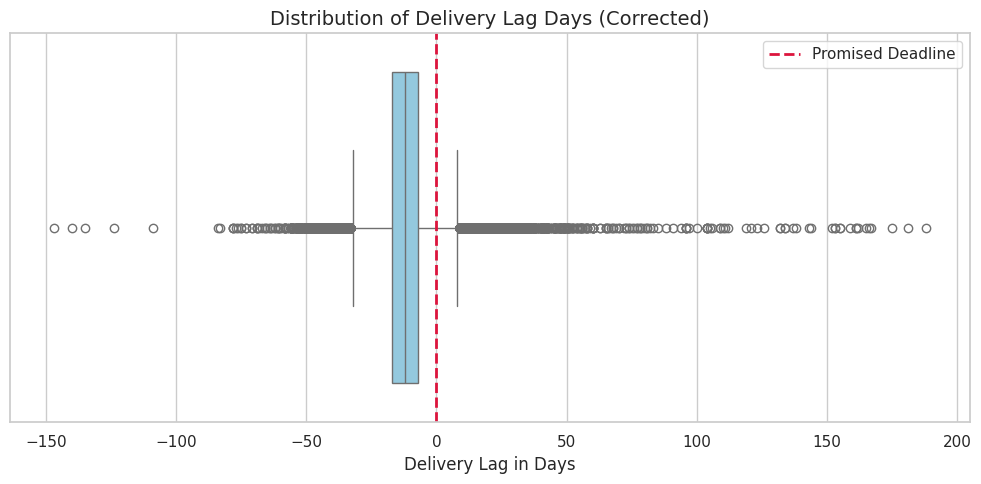

In [68]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# Plot using the corrected column
sns.boxplot(x=df_orders['delivery_lag_days'], color='skyblue', ax=ax)

# Add your target line at 0 days
ax.axvline(x=0, color='crimson', linestyle='--', linewidth=2, label='Promised Deadline')

ax.set_title('Distribution of Delivery Lag Days (Corrected)', fontsize=14)
ax.set_xlabel('Delivery Lag in Days')
ax.legend()

plt.tight_layout()
plt.show()

In [69]:
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_lag_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,-13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,-10.0


In [70]:
# Link orders to products
merged_df = df_orders.merge(df_items, on="order_id")
merged_df = merged_df.merge(df_products, on="product_id")

In [71]:
# Crucial Fix - Bring in 'customer_unique_id' from the customers dataset
merged_df = merged_df.merge(df_customers[["customer_id", "customer_unique_id"]], on="customer_id", how="left")

In [72]:
# Count how many times each unique customer bought from a specific category
customer_counts = merged_df.groupby(["product_category_name", "customer_unique_id"]).size().reset_index(name="purches_counts")

In [73]:
customer_counts.head()

,product_category_name,customer_unique_id,purches_counts
0,agro_industria_e_comercio,01a17507586f0f10f52e7e86ac73e1f7,1
1,agro_industria_e_comercio,0205ecc1296100f97f4ae03e22643b8e,1
2,agro_industria_e_comercio,03a4abdc6deb7b5b3c18b4cde6d63761,1
3,agro_industria_e_comercio,06944904bd31234a78668f4bb962817d,1
4,agro_industria_e_comercio,089c00c6a00d268888c4b66b6ec0c474,1


In [74]:
# Aggregate data to find total unique customers vs. one-time buyers per category
category_churn = (
    customer_counts.groupby("product_category_name")
    .agg(
        total_unique_customers=("customer_unique_id", "nunique"),
        one_time_buyers=("purches_counts", lambda x: (x==1).sum())
        )
    .reset_index()
    )

In [75]:
# Calculate Churn Rate Percentage
category_churn["churn_rate_%"] = category_churn["one_time_buyers"] / category_churn["total_unique_customers"] * 100

In [76]:
category_churn.head()

,product_category_name,total_unique_customers,one_time_buyers,churn_rate_%
0,agro_industria_e_comercio,181,162,89.502762
1,alimentos,445,405,91.011236
2,alimentos_bebidas,225,194,86.222222
3,artes,202,199,98.514851
4,artes_e_artesanato,21,18,85.714286


In [77]:
# Filter out low-volume categories to remove data noise (minimum 100 customers)
filtered_churn = category_churn[category_churn["total_unique_customers"] >= 100]

In [78]:
# Sort by highest churn rate
highest_churn_category = filtered_churn.sort_values(by="churn_rate_%", ascending=False)

In [79]:
# Grab top 10 categories for the plot
top_10_churn = highest_churn_category.head(10)

/tmp/ipykernel_1112/3540224353.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


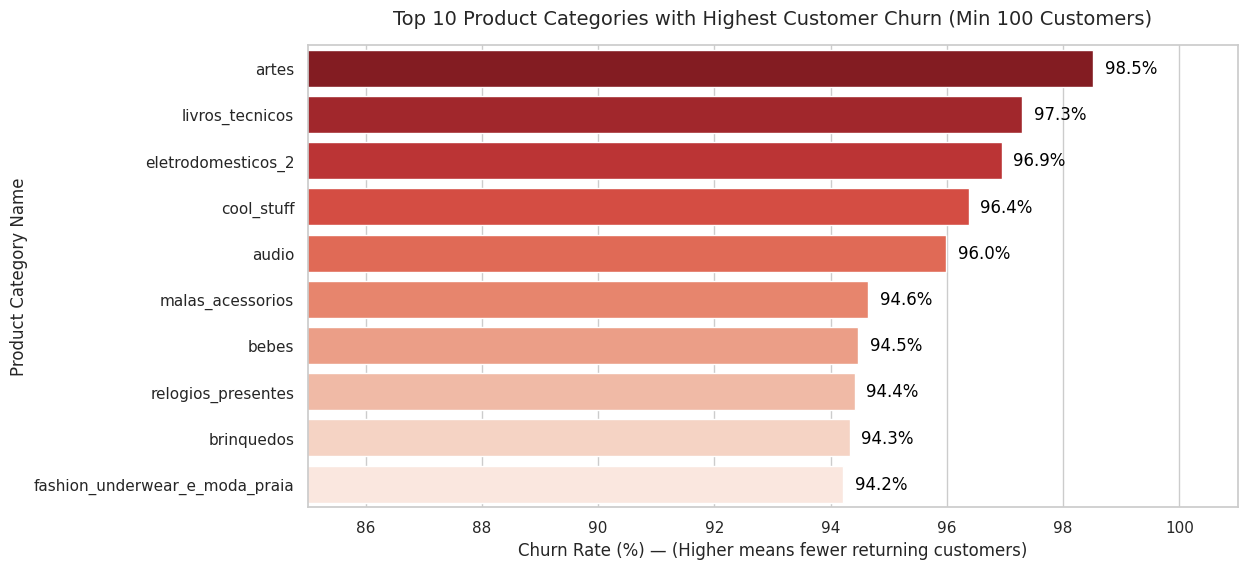

In [80]:
# Set plot aesthetics
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Create horizontal barplot
sns.barplot(
    data=top_10_churn,
    y="product_category_name",
    x="churn_rate_%",
    palette="Reds_r"
    )

# Customize chart text and limits
plt.title(
    "Top 10 Product Categories with Highest Customer Churn (Min 100 Customers)",
    fontsize=14,
    pad=15,
)
plt.xlabel(
    "Churn Rate (%) — (Higher means fewer returning customers)", fontsize=12
)
plt.ylabel("Product Category Name", fontsize=12)

# Zoom in on the high-end spectrum since e-commerce retention sits tight here
plt.xlim(85, 101)

# Annotate the exact percentages onto the bars
for index, value in enumerate(top_10_churn["churn_rate_%"]):
    plt.text(
        value + 0.2, index, f"{value:.1f}%", va="center", color="black"
    )